In [1]:
import torch
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import os,sys
from tqdm import tqdm
import random as random
import matplotlib.pyplot as plt
from IPython.display import Markdown
from scipy.stats import multivariate_normal


sys.path.insert(0, os.path.abspath(".."))
from Parametric.clt_MoM import clt_nested
from Parametric.Phi import theta_to_Sig_diag
from Parametric.Fn_nested import Fn_inverse_nested

from Parametric.utils_model_design import generate_twub_design
from Parametric.utils_plot import plot_MOM_est,plot_conf_bias_sd,qq_plots

# Full-sib half-sib model with 7 unknown parameters

This notebook reproduces the simulation presented in Appendix D.

## Model Setup

Consider an experimental design in which each of the $I_1$ sires is mated with $M$ dams, so that the total number of dams is $I_2=I_1M$. The $m$-th dam mated with the $i$ th sire produces $J_{im}$ offspring, yielding a total sample size $n=\sum_{i=1}^{I_1}\sum_{m=1}^{M}J_{im}$. Let $J_i=\sum_{m=1}^{M}J_{im}$ denote the total number of offspring from sire $i$. For each offspring, we observe $p$ phenotypic traits. The observed trait matrix $Y\in\mathbb{R}^{n\times p}$ is assumed to follow the model
\begin{align*}
    Y=X\beta+U_1\alpha_1+U_2\alpha_2+U_3\alpha_3,
    \qquad
    \alpha_r\sim N(0,\text{Id}_{I_r}\otimes\Sigma_r).
\end{align*}
Here $X=\mathbb{1}_n$ is the fixed-effects design matrix, $\beta=\mu^T$ is the fixed effect,
$$
U_1=\text{diag}(\mathbb{1}_{J_1},\ldots,\mathbb{1}_{J_{I_1}})\in\mathbb{R}^{n\times I_1}
$$
assigns each offspring to its sire,
$$
U_2=\text{diag}(\mathbb{1}_{J_{11}},\ldots,\mathbb{1}_{J_{1M}},\ldots,\mathbb{1}_{J_{I_11}},\ldots,\mathbb{1}_{J_{I_1M}})\in\mathbb{R}^{n\times I_2}
$$
assigns each offspring to its dam, and $U_3=\text{Id}_n$ corresponds to the individual-level error. 

Let 
$$B_1=U_1(U_1^TU_1)^{-1}U_1^T-{1}_n({1}_n^T{1}_n)^{-1}{1}_n^T,\quad, B_2= U_2(U_2^TU_2)^{-1}U_2^T-U_1(U_1^TU_1)^{-1}U_1^T,\quad 
        B_3= U_3(U_3^TU_3)^{-1}U_3^T-U_2(U_2^TU_2)^{-1}U_2^T$$
and consider the sum of squares matrices
$$
S_1= \frac{1}{p}Y^TB_1Y,\quad S_2= \frac{1}{p}Y^TB_2Y,\quad S_3= \frac{1}{p}Y^TB_3Y.
$$

We assume that the eigenvalues of $\Sigma_1$ follow an exponential decay parameterized by $\theta_1=(\tau_1,\rho_1)$, those of $\Sigma_2$ follow a linear decay parameterized by $\theta_2=(\tau_2,\rho_2)$, and those of $\Sigma_3$ follow a step-function model parameterized by $\theta_3=(\tau_3,\tau_4,\rho_3)$:
\begin{align*}
    g_1(x)&=\tau_1\exp(-\rho_1x), \quad g_2(x)=\tau_2(1-\rho_2x)_+, \\
    g_3(x)&=\tau_3\mathbb{1}[0\le x\le \rho_3]+\tau_4\mathbb{1}[\rho_3<x\le 1].
\end{align*}

In [2]:
k = 3; I = 100; p=200; M=2; decay_list = ["exp","linear","step"]
tau1 = 2.; rho1=8; tau2=1.; rho2 =3; tau3 = 1.; tau4 = 0.;rho3 = 0.2

theta1 = torch.tensor([tau1,rho1])
theta2 = torch.tensor([tau2,rho2]) 
theta3 = torch.tensor([tau3,tau4,rho3])
theta_list = [theta1,theta2,theta3]
K_list = [len(theta_list[r]) for r in range(k)]
theta_full = torch.tensor([tau1,rho1,tau2,rho2,tau3,tau4,rho3])

U_list, B_list, J1, J2, n= generate_twub_design(I,M)

cache = f"k_{k}_I_{I}_p_{p}_M_{M}"
for i in range(k):
    cache+="_"+decay_list[i]+"_"+"theta_"+str(i+1)+"_"+str([round(x,1) for x in theta_list[i].tolist()])
if not os.path.exists('cache/'+cache+'/'):
    os.makedirs('cache/'+cache+'/')
    os.makedirs('image/'+cache+'/')
print('cache: ',cache)

[level 3] increment space dimension:  103 , rank of B_3:  103
[level 2] increment space dimension:  100 , rank of B_2:  100
[level 1] increment space dimension:  99 , rank of B_1:  52
cache:  k_3_I_100_p_200_M_2_exp_theta_1_[2.0, 8.0]_linear_theta_2_[1.0, 3.0]_step_theta_3_[1.0, 0.0, 0.2]


In [3]:
print(n,len(J1),len(J2),p)

303 100 200 200


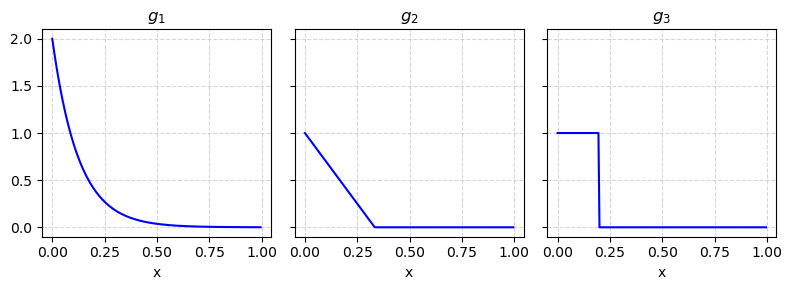

In [4]:
Sigma_diag_list = [theta_to_Sig_diag(theta_list[i],p,decay=decay_list[i]) for i in range(k)]

fig, axes = plt.subplots(1,len(Sigma_diag_list), figsize=(8, 3),sharey=True)  
titles = [r"$g_{1}$",r"$g_{2}$",r"$g_{3}$"]
for i, curve in enumerate(Sigma_diag_list):
    axes[i].plot(np.arange(p)/p,curve,color='blue')
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('x')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'image/{cache}/eigenvalue_decay.pdf', bbox_inches='tight')
plt.show()

# Simulations

In [5]:
thresh = 0.001
rep=1000

def cache_MOM(seed, theta_hat, filename):
    file1 = open(os.path.join('cache/'+cache+'/', filename+".txt"), "a")
    file1.write("\n")
    file1.write(str(seed)+","+str(theta_hat.tolist()))
    file1.close()
    return 

def run_iteration(seed, ifcache = False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    alpha1 = multivariate_normal.rvs(mean=np.zeros(p), cov=np.diag(Sigma_diag_list[0]), size=I)
    alpha2 = multivariate_normal.rvs(mean=np.zeros(p), cov=np.diag(Sigma_diag_list[1]), size=len(J2))
    alpha3 = multivariate_normal.rvs(mean=np.zeros(p), cov=np.diag(Sigma_diag_list[2]), size=n)
    
    Y = np.ones((n,p)) + U_list[0]@alpha1 + U_list[1]@alpha2 + U_list[2]@alpha3

    theta_hat_list = Fn_inverse_nested(Y,B_list,U_list,decay_list,K_list,thresh,seed=seed)

    if ifcache:
        cache_MOM(seed, np.concatenate(theta_hat_list), filename="MoM_est")

    del alpha1, alpha2, alpha3, Y
    return theta_hat_list

for seed in tqdm(range(rep), desc="simulations"):
    with torch.no_grad():
        theta_hat_list = run_iteration(seed,ifcache=True)


simulations:   0%|          | 0/1000 [00:00<?, ?it/s]

simulations: 100%|██████████| 1000/1000 [30:01<00:00,  1.80s/it]


1000  replications


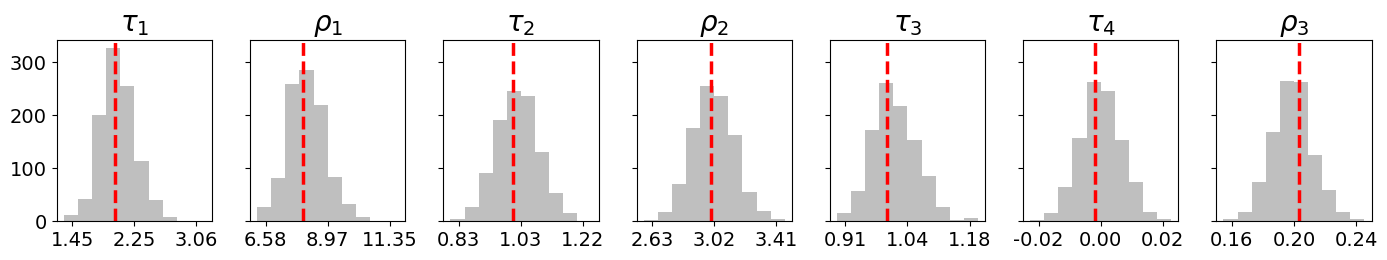

sim bias:  [0.041, 0.1626, 0.0148, 0.0178, 0.0172, 0.0018, -0.0042]
sim sd:  [0.2269, 0.7334, 0.0664, 0.1306, 0.0492, 0.0062, 0.0137]


In [9]:
titles =  [r"$\tau_{1}$",r"$\rho_1$",r"$\tau_{2}$",r"$\rho_2$",r"$\tau_{3}$",r"$\tau_{4}$",r"$\rho_3$"]
cache_dir = f'cache/{cache}/MoM_est.txt'
save_dir = f'image/{cache}/hist_mom_est.pdf'
bias_sim,sd_sim,corr_sim = plot_MOM_est(cache_dir, titles, theta_full, figsize = (14,2.7), save = save_dir)


1000  replications


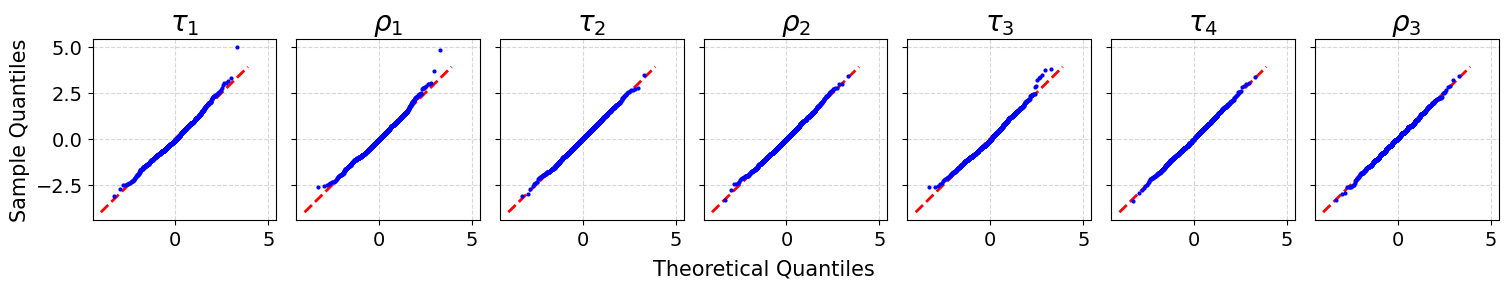

In [10]:
cache_dir = f'cache/{cache}/MoM_est.txt'
save_dir = f'image/{cache}/qq.pdf'
qq_plots(cache_dir, titles, figsize=(15,2.7), save = save_dir)

## Asymptotic bias and standard deviation

In [11]:
bias_theory, cov_theory  = clt_nested(theta_list,B_list,U_list,decay_list,p)

#### Level 3 ####


Evaluating deterministic equivalent LSS...: 100%|██████████| 1000/1000 [00:54<00:00, 18.31it/s]


#### Level 2 ####


Evaluating deterministic equivalent LSS...: 100%|██████████| 1000/1000 [01:45<00:00,  9.44it/s]


#### Level 1 ####


Evaluating deterministic equivalent LSS...: 100%|██████████| 1000/1000 [02:45<00:00,  6.03it/s]


## empirical vs theoretical bias and sd of MOM estimators

In [12]:
sd_theory = torch.sqrt(torch.diag(cov_theory)).tolist()
data_bias_sd = {
    'Parameter': titles,
    'empirical Bias': bias_sim,
    'theoretical Bias': [round(x, 4) for x in bias_theory.tolist()],
    'empirical SD': sd_sim,
    'theoretical SD': [round(x,4) for x in sd_theory]
}

df = pd.DataFrame(data_bias_sd)
Markdown(df.set_index('Parameter').T.to_markdown())


|                  |   $\tau_{1}$ |   $\rho_1$ |   $\tau_{2}$ |   $\rho_2$ |   $\tau_{3}$ |   $\tau_{4}$ |   $\rho_3$ |
|:-----------------|-------------:|-----------:|-------------:|-----------:|-------------:|-------------:|-----------:|
| empirical Bias   |       0.041  |     0.1626 |       0.0148 |     0.0178 |       0.0172 |       0.0018 |    -0.0042 |
| theoretical Bias |       0.0572 |     0.2373 |       0.0174 |    -0.0077 |       0.0195 |       0.0025 |    -0.0095 |
| empirical SD     |       0.2269 |     0.7334 |       0.0664 |     0.1306 |       0.0492 |       0.0062 |     0.0137 |
| theoretical SD   |       0.222  |     0.7096 |       0.0667 |     0.13   |       0.047  |       0.0061 |     0.0131 |

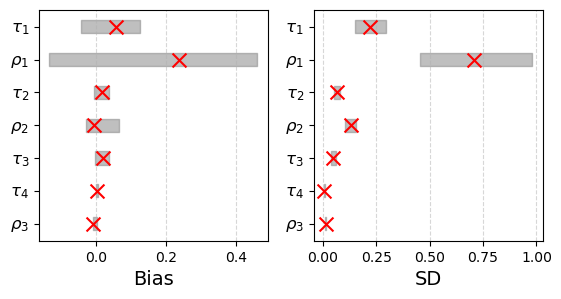

In [13]:
cache_dir = f'cache/{cache}/MoM_est.txt'
save_dir = f'image/{cache}/conf_bias_sd.pdf'
plot_conf_bias_sd(cache_dir,titles,theta_full,bias_theory, sd_theory,save=save_dir)